In [15]:
# Install what we need
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("All set! Let's detect some fraud 🕵️")

All set! Let's detect some fraud 🕵️


In [16]:
# Load it
df = pd.read_csv('/content/creditcard.csv')

print(f"Got {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Frauds: {df['Class'].sum()} out of {len(df)} ({df['Class'].mean()*100:.3f}%)")
print("\nFirst look:")
df.head()

Got 284807 rows and 31 columns
Frauds: 492 out of 284807 (0.173%)

First look:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# See the class imbalance clearly
print("\nClass breakdown:")
print(df['Class'].value_counts())

# Basic stats
df.describe()

Missing values: 0

Class breakdown:
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


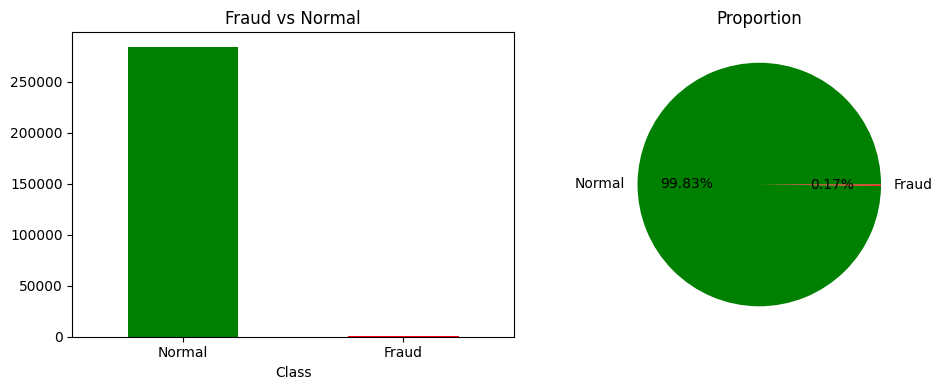

Yeah... 0.17% fraud. This is gonna be tricky.


In [18]:
# Plot class distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Fraud vs Normal')
plt.xticks([0, 1], ['Normal', 'Fraud'], rotation=0)

plt.subplot(1, 2, 2)
labels = ['Normal', 'Fraud']
sizes = df['Class'].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=['green', 'red'])
plt.title('Proportion')

plt.tight_layout()
plt.show()

print("Yeah... 0.17% fraud. This is gonna be tricky.")

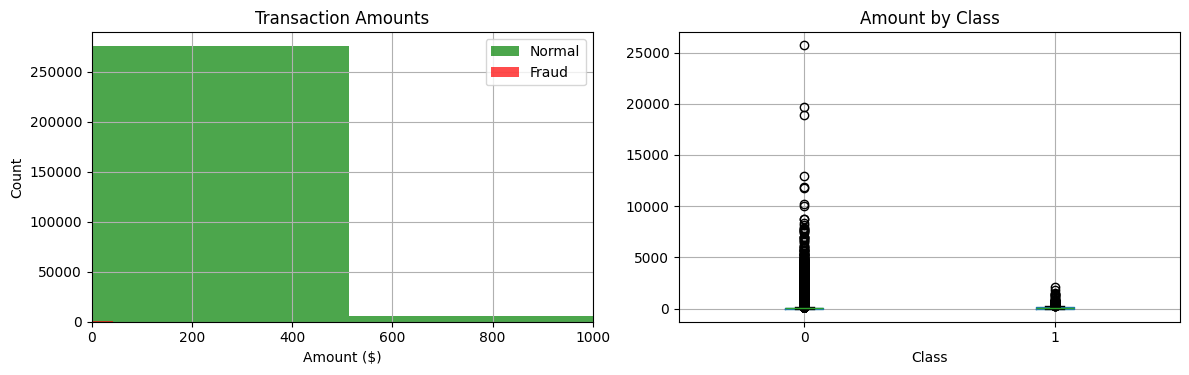

In [19]:
# Fraud amounts vs normal amounts
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.7, label='Normal', color='green')
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', color='red')
plt.xlabel('Amount ($)')
plt.ylabel('Count')
plt.title('Transaction Amounts')
plt.legend()
plt.xlim(0, 1000)  # Most transactions are small

plt.subplot(1, 2, 2)
df.boxplot(column='Amount', by='Class', ax=plt.gca())
plt.title('Amount by Class')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

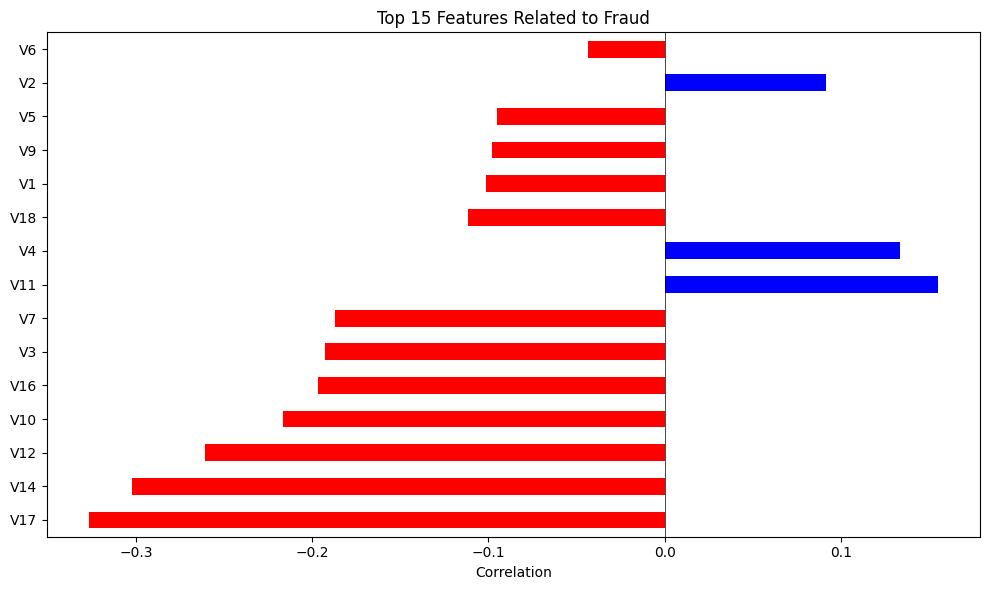

V14, V4, V10 seem important. Good to know.


In [20]:
# See correlation with fraud
correlations = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='barh', color=['red' if x < 0 else 'blue' for x in correlations.head(15)])
plt.title('Top 15 Features Related to Fraud')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("V14, V4, V10 seem important. Good to know.")

In [21]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time (they're on different scales)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train frauds: {y_train.sum()}, Test frauds: {y_test.sum()}")

Train: (227845, 30), Test: (56962, 30)
Train frauds: 394, Test frauds: 98


In [22]:
print("Before SMOTE:")
print(f"Normal: {(y_train==0).sum()}, Fraud: {(y_train==1).sum()}")

# Apply SMOTE - creates synthetic fraud examples
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Normal: {(y_train_bal==0).sum()}, Fraud: {(y_train_bal==1).sum()}")
print("Much better balance now!")

Before SMOTE:
Normal: 227451, Fraud: 394

After SMOTE:
Normal: 227451, Fraud: 113725
Much better balance now!


In [23]:
# Simple model first
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Results
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Results:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9694


In [24]:
# Better model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_bal, y_train_bal)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Results
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.46      0.87      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9807


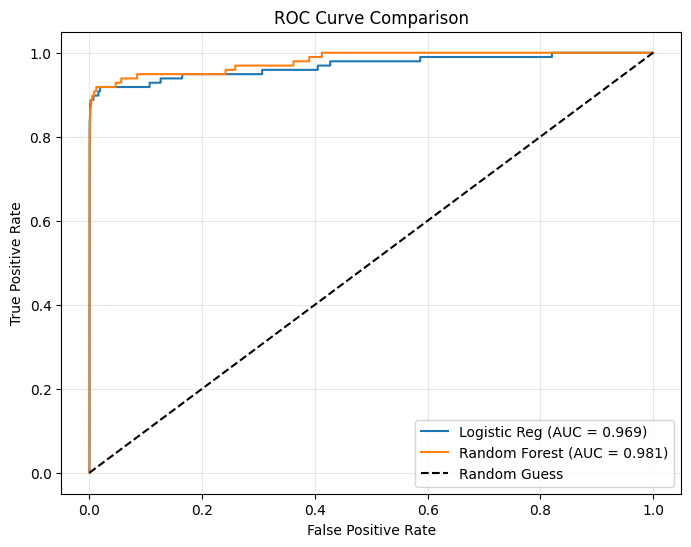

Random Forest wins! 🎉


In [25]:
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Random Forest wins! 🎉")

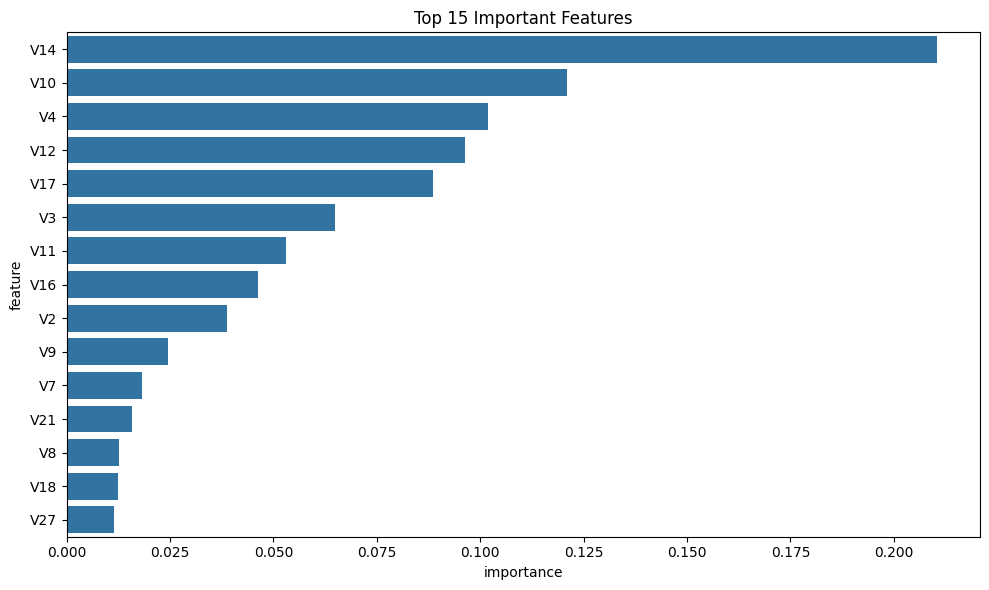

In [26]:
# Feature importance from Random Forest
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance.head(15))
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()

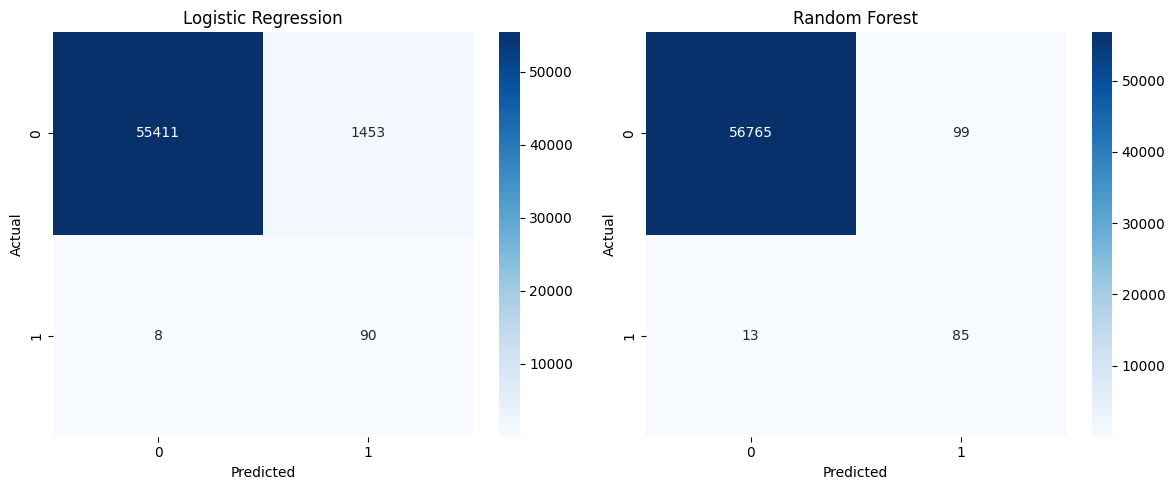

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()